# 05 - Evaluación: Evaluación Comparativa de Modelos

**Fase del Pipeline DSR: Evaluación y Recomendación de Despliegue**

Este notebook realiza la evaluación comparativa completa de los 4 modelos
de detección de anomalías no supervisados usando:
- **Métricas intrínsecas:** Silhouette, Davies-Bouldin, Calinski-Harabasz (calidad del cluster)
- **Métricas extrínsecas:** Accuracy, Sensibilidad, Especificidad, F1, AUC-ROC (vs verdad de campo AAMI)
- **Métricas de eficiencia:** Tiempo de entrenamiento, uso máximo de memoria

El `ModelComparator` ejecuta todos los modelos y produce una tabla de comparación unificada.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from ecg_anomaly.config import SystemConfig
from ecg_anomaly.seeding import set_global_seed
from ecg_anomaly.cache import get_or_build_preprocessed
from ecg_anomaly.data.splitting import make_normal_fit_split
from ecg_anomaly.features.manual import ManualFeatureExtractor
from ecg_anomaly.evaluation.comparator import ModelComparator
from ecg_anomaly.evaluation.extrinsic import evaluate_extrinsic
from ecg_anomaly.evaluation.intrinsic import evaluate_intrinsic
from ecg_anomaly.visualization.reports import plot_metrics_comparison, plot_confusion_matrices
from ecg_anomaly.visualization.clusters import plot_pca_scatter
from ecg_anomaly.visualization.labels import LABELS_ES

sns.set_style("whitegrid")
config = SystemConfig.from_yaml("../config/default.yaml")
config.setup_logging()
set_global_seed(config.random_seed)

## 1. Preparar Datos (Pipeline Completo)

In [2]:
preprocessed = get_or_build_preprocessed(config)

# Split solo-normal: evita fuga de datos en el escalado del autoencoder
# (ver guia de mejoras #1, y la nota metodologica mas abajo)
fit_idx, eval_idx = make_normal_fit_split(preprocessed, seed=config.random_seed)

# Path B: Manual features con ventanas temporales (22 features)
extractor = ManualFeatureExtractor()
X_clustering = extractor.extract(
    preprocessed.segments,
    preprocessed.r_peaks_flat,
    config.sampling_rate,
    preprocessed.record_indices,
)
# El scaler del autoencoder se ajusta SOLO con normales (fit_idx) y se
# aplica a todo el dataset: el autoencoder debe aprender como es un
# latido normal sin haber "visto" anomalias ni normales de evaluacion.
ae_scaler = StandardScaler()
ae_scaler.fit(preprocessed.segments[fit_idx])
X_autoencoder = ae_scaler.transform(preprocessed.segments)
true_labels = preprocessed.labels

# PCA 2D for visualization only
pca_vis = PCA(n_components=2, random_state=42)
X_pca_vis = pca_vis.fit_transform(X_clustering)

print(f"Dataset: {preprocessed.metadata['n_beats']:,} beats from {preprocessed.metadata['n_records']} records")
print(f"Clustering features (Manual 22d): {X_clustering.shape}")
print(f"Autoencoder features (raw): {X_autoencoder.shape}")
print(f"Fit solo-normal: {len(fit_idx):,} | Eval: {len(eval_idx):,}")
print(f"Class distribution: Normal={int(np.sum(true_labels==0)):,}, Anomalous={int(np.sum(true_labels==1)):,}")

18:17:28 [ecg_anomaly.data.loader] INFO: Cargados 44 registros: 100733 latidos (90125 normal, 10608 anomalo)
18:17:29 [ecg_anomaly.preprocessing.pipeline] INFO: Preprocesamiento completo: 100705 latidos [100705, 200] (normal=90099, anomalo=10606)
18:18:06 [ecg_anomaly.features.manual] INFO: Features manuales: 100705 latidos x 22 features


Dataset: 100,705 beats from 44 records
Clustering features (Manual 22d): (100705, 22)
Autoencoder features (raw): (100705, 200)
Class distribution: Normal=90,099, Anomalous=10,606


**Por que un split solo-normal:** ajustar el `StandardScaler` (y, en la Ruta A, el PCA) sobre todo el dataset -- incluyendo lo que luego se evalua -- contamina la estimacion de rendimiento del autoencoder. El estandar en deteccion de anomalias es aprender la representacion de "normalidad" solo con latidos normales (`fit_idx`) y aplicarla al resto (`eval_idx` = normales restantes + todas las anomalias), para que las anomalias destaquen por su error de reconstruccion. Por eso el autoencoder tambien se entrena mas abajo solo con `X_autoencoder[fit_idx]` (ver seccion 2). Para los modelos de clustering puro (K-Means, DBSCAN, HDBSCAN) este split es buena practica pero opcional, porque no hay entrenamiento supervisado que pueda sobreajustarse: siguen usando `X_clustering` completo. Ver guia de mejoras #1.

## 1b. ¿Por qué métricas intrínsecas y extrínsecas?

### Métricas Intrínsecas (No supervisadas)
Silhouette, Davies-Bouldin y Calinski-Harabasz evalúan la **calidad geométrica** de los clusters sin usar etiquetas. Esto refleja el escenario no supervisado real donde no hay ground truth disponible. Un Silhouette alto y Davies-Bouldin bajo indican clusters bien separados, condición necesaria para una detección de anomalías confiable.

### Métricas Extrínsecas (Evaluación supervisada)
Accuracy, Sensitivity, Specificity, F1 y AUC-ROC comparan las predicciones contra el estándar de oro clínico AAMI. Esto permite:
1. **Cuantificar el rendimiento clínico** de cada método
2. **Comparar contra la literatura publicada**
3. **Identificar tipos de error** (FP vs FN) que comete cada método

### ¿Por qué ambas?
Las métricas intrínsecas indican si el modelo encuentra **estructura geométrica significativa**. Las extrínsecas indican si esa estructura **corresponde a patología real**. Un modelo puede tener excelente geometría (Silhouette alto) pero mal alineamiento clínico (F1 bajo), o viceversa. Ambas perspectivas son necesarias para una evaluación completa.

**Nota clínica:** En el screening ECG médico, **los falsos negativos (anomalías no detectadas) son más críticos** que los falsos positivos (falsas alarmas). Un modelo que omite anomalías es clínicamente inútil sin importar su Accuracy. Por lo tanto, **Sensitivity** es una métrica clave a monitorear.

## 1c. Asignación heurística cluster-a-clase

Los cuatro métodos usan **reglas heurísticas** para mapear salidas no supervisadas a etiquetas binarias normal/anómalo:

| Método | Regla Heurística |
|--------|------------------|
| K-Means | Cluster minoritario (por tamaño) = anómalo |
| DBSCAN | Puntos de ruido (etiqueta = -1) = anómalo |
| HDBSCAN | Puntos de ruido (etiqueta = -1) = anómalo |
| Autoencoder | Latidos con error de reconstrucción > percentil umbral = anómalo |

**Limitación:** Estos supuestos deben validarse clínicamente. Por ejemplo, K-Means asume que el cluster más pequeño siempre contiene latidos patológicos, pero podría capturar una variante normal o artefactos. La siguiente celda prueba ambas direcciones de asignación para K-Means.

**Explicación de la validación:**

Este bloque verifica si la heurística por defecto de K-Means
(cluster minoritario = anómalo) es clínicamente correcta.
K-Means separa los datos en 2 clusters pero no sabe cuál es
normal y cuál es anómalo — la asignación es puramente geométrica.

Se prueban ambas direcciones contra el ground truth AAMI:
- **Asignación A**: cluster mayoritario = normal (heurística por defecto)
- **Asignación B**: cluster minoritario = normal (heurística invertida)

Si la asignación B obtiene mejor F1, la heurística por defecto
no es óptima para estos datos, lo que significa que el cluster
más grande podría contener las anomalías en lugar del más pequeño.

> **Nota metodológica:** La comparación de asignaciones A/B que sigue es un *análisis post-hoc de sensibilidad*, no parte del método de detección. En despliegue real, la asignación cluster→clase se define por una heurística no supervisada (cluster mayoritario = normal, sin mirar las etiquetas). Aquí solo cuantificamos cuánto rendimiento se pierde cuando esa heurística no coincide con la asignación óptima según el ground truth AAMI.

In [3]:
# Ejecutar el comparador PRIMERO y reutilizar su K-Means ya entrenado
# en vez de re-entrenarlo aqui (ver guia de mejoras #7: evita ajustar
# K-Means dos veces, cada vez con la posibilidad de una particion
# distinta si no se fija random_state en ambos sitios).
comparator = ModelComparator(config)
results_df = comparator.run_all(
    X_clustering, X_autoencoder, true_labels, autoencoder_fit_idx=fit_idx
)

kmeans_idx = config.models.index("kmeans")
kmeans = comparator.detectors[kmeans_idx]  # mismo objeto, mismas labels_

unique, counts = np.unique(kmeans.labels_, return_counts=True)
majority = unique[np.argmax(counts)]
minority = unique[np.argmin(counts)]

# Asignacion A: cluster mayoritario = normal (heuristica por defecto)
labels_a = np.where(kmeans.labels_ == majority, 0, 1)
metrics_a = evaluate_extrinsic(true_labels, labels_a)

# Asignacion B: cluster minoritario = normal (heuristica invertida)
labels_b = np.where(kmeans.labels_ == minority, 0, 1)
metrics_b = evaluate_extrinsic(true_labels, labels_b)

print("Comparacion de asignaciones K-Means:")
print(f"  Tamano clusters: mayoritario={counts[np.argmax(counts)]:,}, "
      f"minoritario={counts[np.argmin(counts)]:,}")
print(f"  Asignacion A (cluster {majority} = normal, cluster {minority} = anomalo):")
print(f"    F1={metrics_a['f1']:.4f}, Sensitivity={metrics_a['sensitivity']:.4f}, "
      f"Specificity={metrics_a['specificity']:.4f}")
print(f"  Asignacion B (cluster {minority} = normal, cluster {majority} = anomalo):")
print(f"    F1={metrics_b['f1']:.4f}, Sensitivity={metrics_b['sensitivity']:.4f}, "
      f"Specificity={metrics_b['specificity']:.4f}")

best = 'A' if metrics_a['f1'] >= metrics_b['f1'] else 'B'
print(f"\nMejor asignacion por F1: Asignacion {best}")
if best == 'B':
    print("  -> El cluster minoritario produce mejor alineacion clinica.")
    print("  -> Esto significa que la heuristica por defecto (mayoritario=normal) puede no ser siempre optima.")

Comparacion de asignaciones K-Means:
  Tamano clusters: mayoritario=30,209, minoritario=1
  Asignacion A (cluster 3 = normal, cluster 1 = anomalo):
    F1=0.0897, Sensitivity=0.3429, Specificity=0.2579
  Asignacion B (cluster 1 = normal, cluster 3 = anomalo):
    F1=0.1905, Sensitivity=0.9999, Specificity=0.0000

Mejor asignacion por F1: Asignacion B
  -> El cluster minoritario produce mejor alineacion clinica.
  -> Esto significa que la heuristica por defecto (mayoritario=normal) puede no ser siempre optima.


## 1d. Etiquetas AAMI: Solo para evaluación

**Importante:** Las anotaciones AAMI (normal vs anómalo) se usan **EXCLUSIVAMENTE para evaluación**, nunca durante el entrenamiento del modelo. Esto asegura:

- La comparación es **justa** entre los 4 métodos
- Los resultados reflejan un **escenario real de despliegue no supervisado**
- Cualquier alineación con etiquetas clínicas es **descubierta**, no impuesta

La naturaleza no supervisada de los 4 métodos se preserva en todo el pipeline.

## 2. Ejecutar Evaluación Comparativa

El `ModelComparator` entrena cada modelo, mide la eficiencia y calcula
todas las métricas intrínsecas y extrínsecas en una sola pasada.

In [4]:
# El comparador ya se ejecuto en la seccion 1c (celda de validacion A/B)
# para poder reutilizar el K-Means entrenado alli (ver guia de mejoras #7).
print("\nComparative evaluation complete.")
print(f"Models evaluated: {len(comparator.results)}")

18:18:12 [ecg_anomaly.evaluation.comparator] INFO: Evaluando kmeans...
18:21:26 [ecg_anomaly.evaluation.comparator] INFO: kmeans completado: F1=0.434, Silhouette=0.155, Tiempo=5.70s
18:21:26 [ecg_anomaly.evaluation.comparator] INFO: Evaluando dbscan...
18:21:44 [ecg_anomaly.models.dbscan] INFO: DBSCAN eps auto-optimizado (p75): 0.9311
18:23:53 [ecg_anomaly.evaluation.comparator] INFO: dbscan completado: F1=0.315, Silhouette=-0.349, Tiempo=31.84s
18:23:53 [ecg_anomaly.evaluation.comparator] INFO: Evaluando hdbscan...
18:30:22 [ecg_anomaly.models.hdbscan_model] INFO: HDBSCAN: 232 clusters, 47923 ruido (47.6%)
18:31:11 [ecg_anomaly.evaluation.comparator] INFO: hdbscan completado: F1=0.256, Silhouette=0.276, Tiempo=388.98s
18:31:11 [ecg_anomaly.evaluation.comparator] INFO: Evaluando autoencoder...
I0000 00:00:1782343876.765394   29756 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782343918.805915   29756 cudart_stub.cc:31] Could not find


Comparative evaluation complete.
Models evaluated: 4


## 3. Tabla de Comparación

In [5]:
# Display the full comparison table
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
display(results_df.round(4))

,Modelo,Silhouette,Davies-Bouldin,Calinski-Harabasz,Accuracy,Sensitivity,Specificity,F1,AUC-ROC,Tiempo (s),Memoria (MB),Anomalias
0,kmeans,0.1549,1.1626,15484.3949,0.8556,0.5264,0.8943,0.4343,0.7104,5.7028,33.87,15106
1,dbscan,-0.3485,1.1815,106.3850,0.7934,0.4508,0.8338,0.3149,0.6423,31.8364,48.90,19758
2,hdbscan,0.2757,1.1321,2480.7340,0.5677,0.7070,0.5513,0.2562,0.6291,388.9751,48.39,47923
3,autoencoder,NaN,NaN,NaN,0.8633,0.3497,0.9238,0.3502,0.6368,126.9953,395.83,10574


In [6]:
# Highlight key metrics
key_metrics = ["Modelo", "Accuracy", "Sensitivity", "Specificity", "F1", "AUC-ROC", "Silhouette", "Tiempo (s)"]
available = [c for c in key_metrics if c in results_df.columns]
display(results_df[available].round(4))

,Modelo,Accuracy,Sensitivity,Specificity,F1,AUC-ROC,Silhouette,Tiempo (s)
0,kmeans,0.8556,0.5264,0.8943,0.4343,0.7104,0.1549,5.7028
1,dbscan,0.7934,0.4508,0.8338,0.3149,0.6423,-0.3485,31.8364
2,hdbscan,0.5677,0.7070,0.5513,0.2562,0.6291,0.2757,388.9751
3,autoencoder,0.8633,0.3497,0.9238,0.3502,0.6368,NaN,126.9953


## 4. Gráficos de Comparación de Métricas

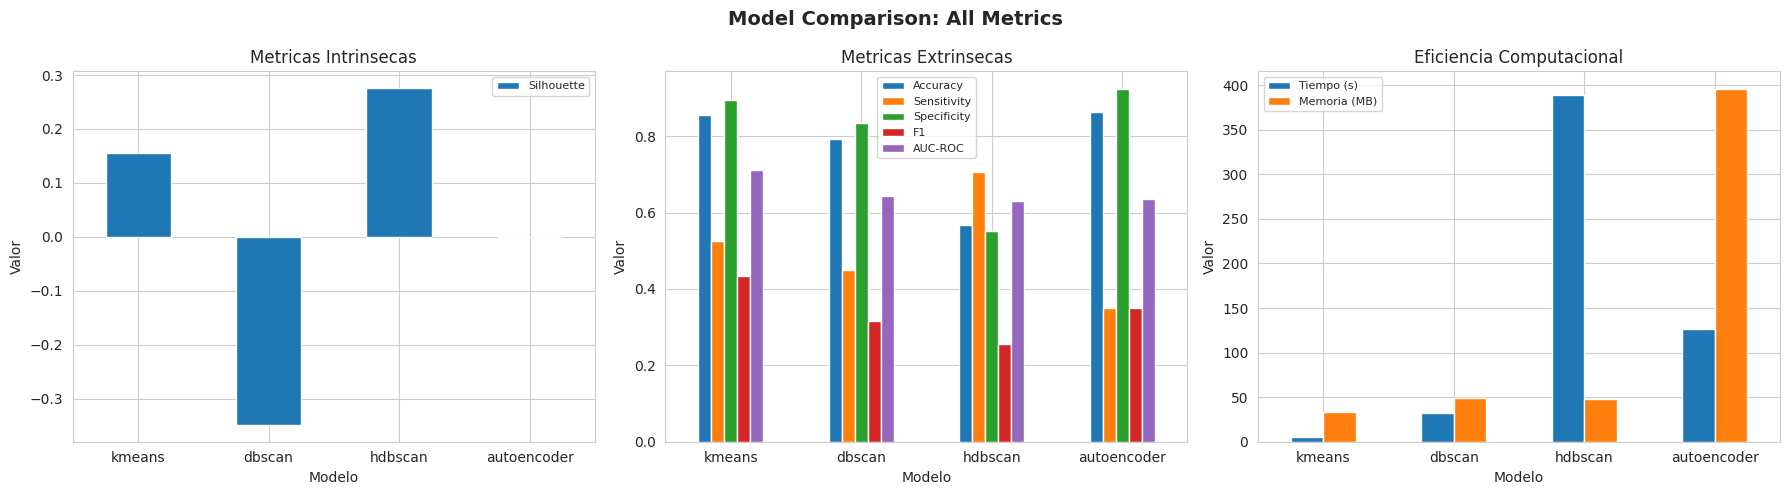

In [7]:
plot_metrics_comparison(results_df, title="Model Comparison: All Metrics")

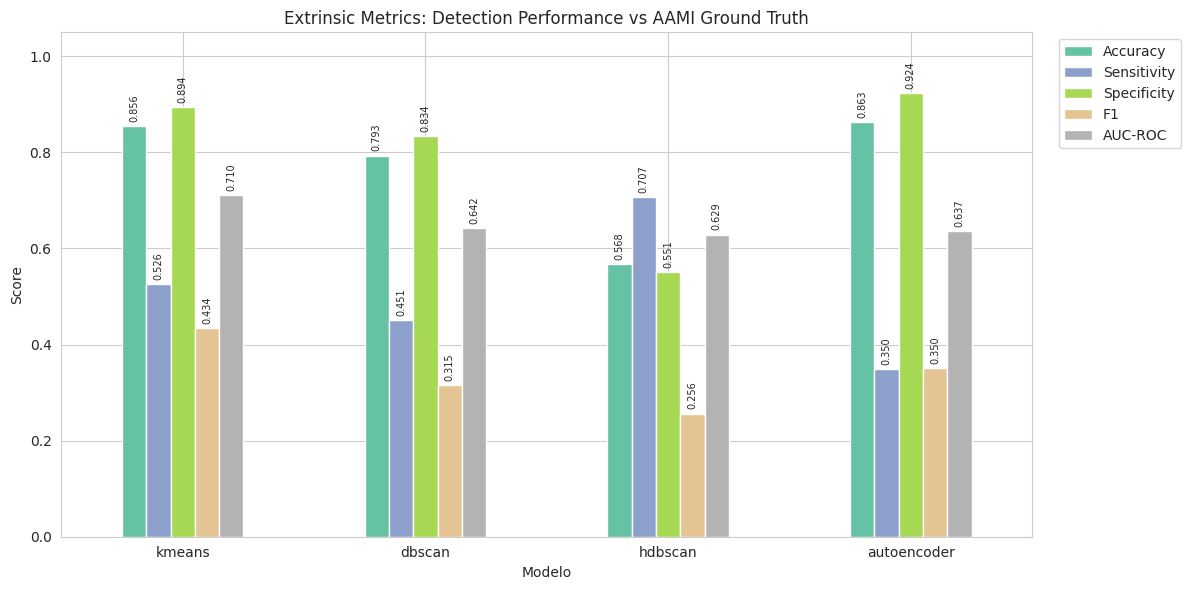

In [8]:
# Focused extrinsic metrics bar chart
extrinsic_cols = ["Accuracy", "Sensitivity", "Specificity", "F1", "AUC-ROC"]
available_ext = [c for c in extrinsic_cols if c in results_df.columns]

if available_ext:
    plot_data = results_df[["Modelo"] + available_ext].set_index("Modelo")
    plot_data = plot_data.apply(pd.to_numeric, errors="coerce")

    fig, ax = plt.subplots(figsize=(12, 6))
    plot_data.plot(kind="bar", ax=ax, rot=0, colormap="Set2")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_title(LABELS_ES["Extrinsic Metrics: Detection Performance vs AAMI Ground Truth"])
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=7, rotation=90, padding=3)

    plt.tight_layout()
    plt.show()

## 5. Matrices de Confusión

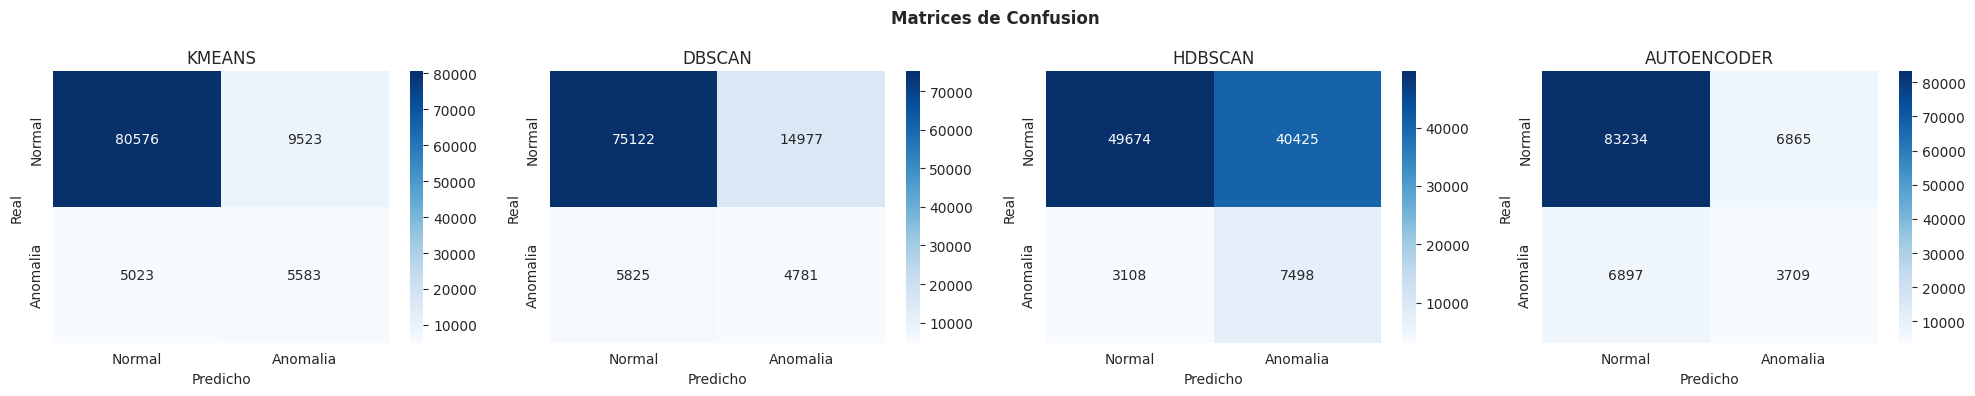

In [9]:
plot_confusion_matrices(comparator.results)

In [10]:
# Detailed confusion matrix breakdown
for result in comparator.results:
    model = result["model"]
    tp = result.get("extrinsic_true_positives", 0)
    fp = result.get("extrinsic_false_positives", 0)
    tn = result.get("extrinsic_true_negatives", 0)
    fn = result.get("extrinsic_false_negatives", 0)
    print(f"\n{model.upper()}:")
    print(f"  True Positives (correct anomalies):  {tp:,}")
    print(f"  False Positives (false alarms):      {fp:,}")
    print(f"  True Negatives (correct normals):    {tn:,}")
    print(f"  False Negatives (missed anomalies):  {fn:,}")


KMEANS:
  True Positives (correct anomalies):  5,583
  False Positives (false alarms):      9,523
  True Negatives (correct normals):    80,576
  False Negatives (missed anomalies):  5,023

DBSCAN:
  True Positives (correct anomalies):  4,781
  False Positives (false alarms):      14,977
  True Negatives (correct normals):    75,122
  False Negatives (missed anomalies):  5,825

HDBSCAN:
  True Positives (correct anomalies):  7,498
  False Positives (false alarms):      40,425
  True Negatives (correct normals):    49,674
  False Negatives (missed anomalies):  3,108

AUTOENCODER:
  True Positives (correct anomalies):  3,709
  False Positives (false alarms):      6,865
  True Negatives (correct normals):    83,234
  False Negatives (missed anomalies):  6,897


## 6. Dispersión PCA: Verdad de Campo vs Predicciones

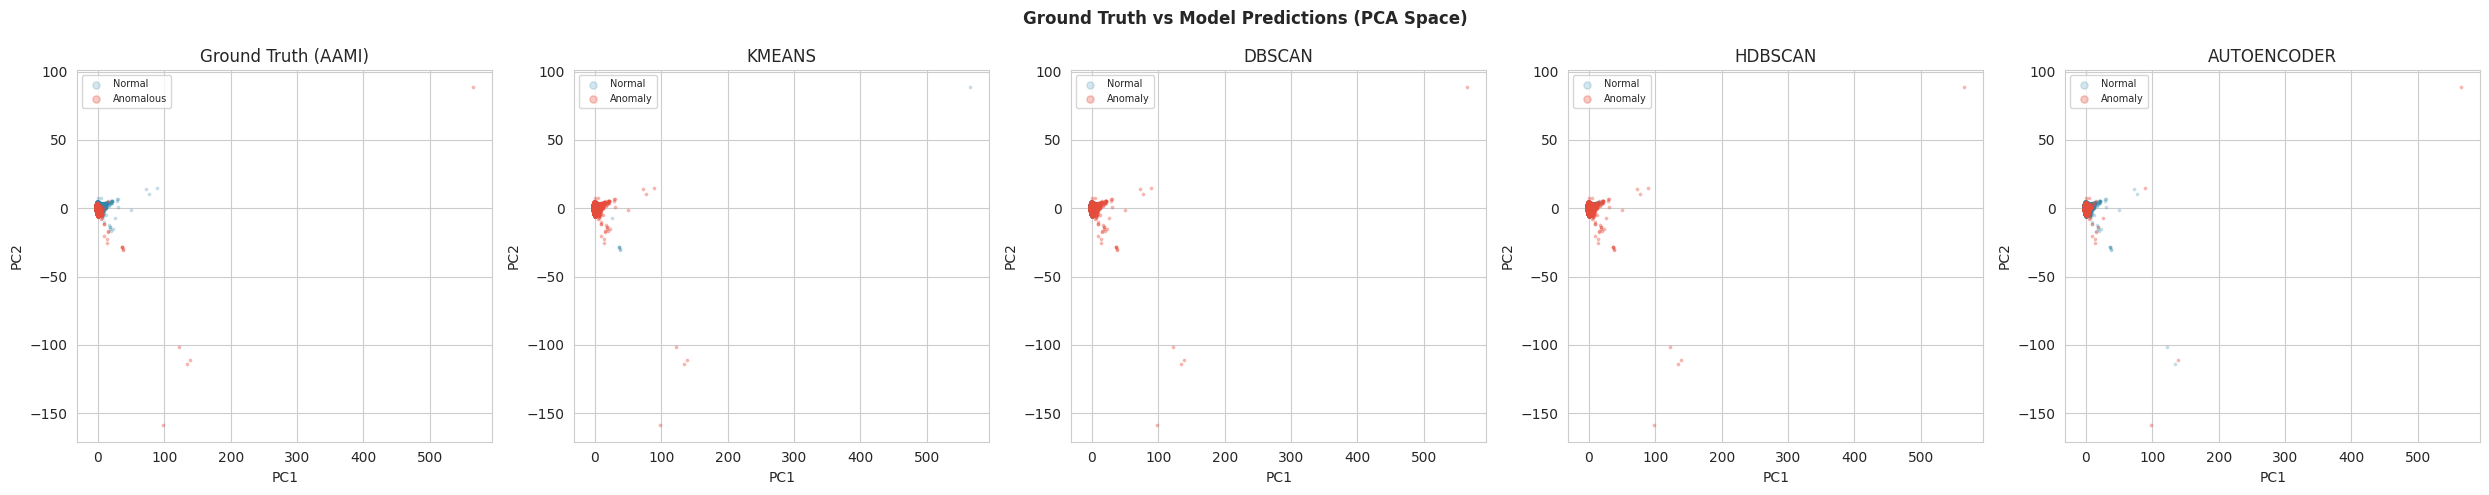

In [11]:
fig, axes = plt.subplots(1, len(config.models) + 1, figsize=(5 * (len(config.models) + 1), 5))

# Ground truth
normal_mask = true_labels == 0
anomaly_mask = true_labels == 1
axes[0].scatter(X_pca_vis[normal_mask, 0], X_pca_vis[normal_mask, 1],
               alpha=0.2, s=3, c="#2E86AB", label="Normal")
axes[0].scatter(X_pca_vis[anomaly_mask, 0], X_pca_vis[anomaly_mask, 1],
               alpha=0.3, s=3, c="#E74C3C", label=LABELS_ES["Anomalous"])
axes[0].set_title(LABELS_ES["Ground Truth (AAMI)"])
axes[0].legend(fontsize=7, markerscale=3)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# Each model's predictions
for i, model_name in enumerate(config.models):
    detector = comparator.detectors[i]
    if detector.anomaly_labels_ is not None:
        pred_normal = detector.anomaly_labels_ == 0
        pred_anomaly = detector.anomaly_labels_ == 1
        axes[i+1].scatter(X_pca_vis[pred_normal, 0], X_pca_vis[pred_normal, 1],
                         alpha=0.2, s=3, c="#2E86AB", label="Normal")
        axes[i+1].scatter(X_pca_vis[pred_anomaly, 0], X_pca_vis[pred_anomaly, 1],
                         alpha=0.3, s=3, c="#E74C3C", label=LABELS_ES["Anomaly"])
        axes[i+1].legend(fontsize=7, markerscale=3)
    axes[i+1].set_title(f"{model_name.upper()}")
    axes[i+1].set_xlabel("PC1")
    axes[i+1].set_ylabel("PC2")

plt.suptitle(LABELS_ES["Ground Truth vs Model Predictions (PCA Space)"], fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Comparación de Eficiencia

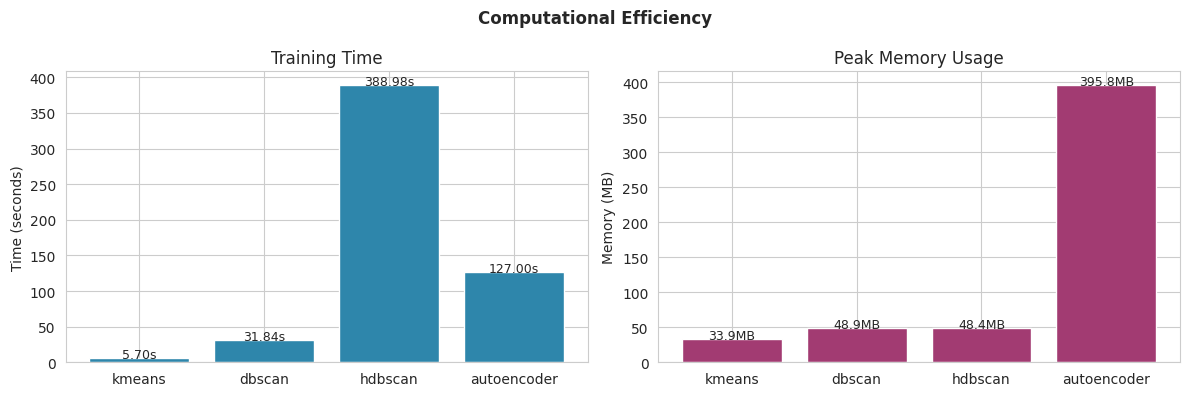

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = [r["model"] for r in comparator.results]
times = [r.get("efficiency_time_seconds", 0) for r in comparator.results]
memory = [r.get("efficiency_peak_memory_mb", 0) for r in comparator.results]

axes[0].bar(models, times, color="#2E86AB")
axes[0].set_ylabel(LABELS_ES["Time (seconds)"])
axes[0].set_title(LABELS_ES["Training Time"])
for i, v in enumerate(times):
    axes[0].text(i, v + 0.01, f"{v:.2f}s", ha="center", fontsize=9)

axes[1].bar(models, memory, color="#A23B72")
axes[1].set_ylabel(LABELS_ES["Memory (MB)"])
axes[1].set_title(LABELS_ES["Peak Memory Usage"])
for i, v in enumerate(memory):
    axes[1].text(i, v + 0.01, f"{v:.1f}MB", ha="center", fontsize=9)

plt.suptitle(LABELS_ES["Computational Efficiency"], fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Selección del Mejor Modelo

In [13]:
# Determine best model by F1 score
best_f1 = comparator.get_best_model(metric="extrinsic_f1")
best_acc = comparator.get_best_model(metric="extrinsic_accuracy")
best_sens = comparator.get_best_model(metric="extrinsic_sensitivity")
best_time = comparator.get_best_model(metric="efficiency_time_seconds")

print("Best model by metric:")
print(f"  F1 Score:    {best_f1}")
print(f"  Accuracy:    {best_acc}")
print(f"  Sensitivity: {best_sens}")
print(f"  Speed:       {best_time}")
print()
print(f"Overall recommendation (by F1): {best_f1}")

Best model by metric:
  F1 Score:    kmeans
  Accuracy:    autoencoder
  Sensitivity: hdbscan
  Speed:       kmeans

Overall recommendation (by F1): kmeans


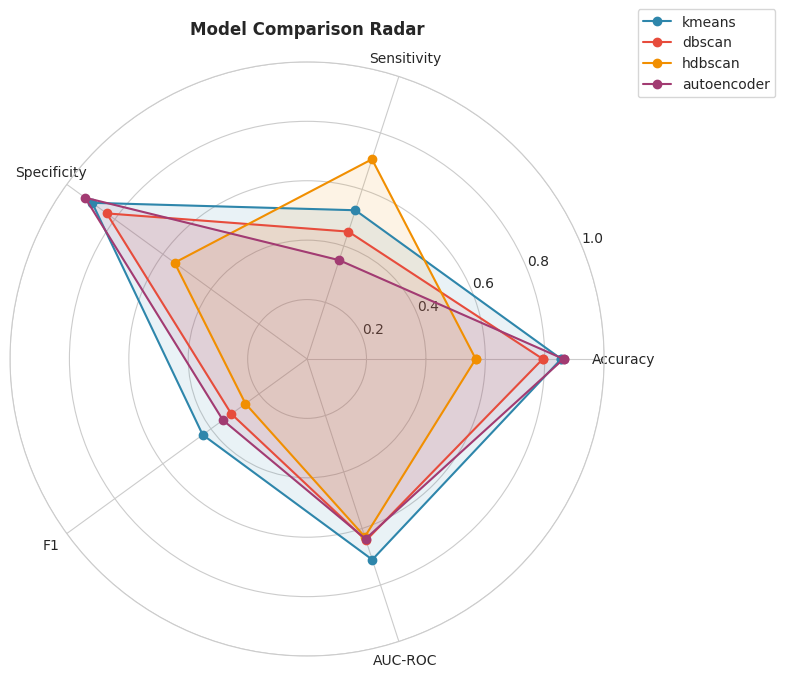

In [14]:
# Radar chart for multi-metric comparison
radar_metrics = ["Accuracy", "Sensitivity", "Specificity", "F1", "AUC-ROC"]
available_radar = [m for m in radar_metrics if m in results_df.columns]

if len(available_radar) >= 3:
    from matplotlib.patches import FancyBboxPatch
    angles = np.linspace(0, 2 * np.pi, len(available_radar), endpoint=False).tolist()
    angles += angles[:1]  # close the polygon

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    colors = ["#2E86AB", "#E74C3C", "#F18F01", "#A23B72"]

    for i, row in results_df.iterrows():
        values = [float(row[m]) if pd.notna(row[m]) else 0 for m in available_radar]
        values += values[:1]
        ax.plot(angles, values, "o-", linewidth=1.5, label=row["Modelo"],
                color=colors[i % len(colors)])
        ax.fill(angles, values, alpha=0.1, color=colors[i % len(colors)])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(available_radar)
    ax.set_ylim(0, 1)
    ax.set_title(LABELS_ES["Model Comparison Radar"], pad=20, fontweight="bold")
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

## 9. Ranking Multi-Criterio (Puntuación Compuesta)

Cada métrica captura un aspecto diferente de la calidad del modelo. Para obtener un **ranking único**
que equilibre todos los criterios, calculamos una puntuación compuesta ponderada:

| Métrica | Peso | Justificación |
|--------|--------|----------|
| F1 | 25% | Precisión de detección primaria (precisión + recall) |
| Sensibilidad | 20% | Crítico: anomalías no detectadas son clínicamente peligrosas |
| Especificidad | 10% | Evita falsas alarmas |
| Accuracy | 10% | Corrección general |
| AUC-ROC | 10% | Capacidad de discriminación entre umbrales |
| Silhouette | 10% | Calidad de separación de clusters (no supervisado) |
| Davies-Bouldin | 5% | Compacidad del cluster (invertido, menor es mejor) |
| Tiempo | 5% | Velocidad de entrenamiento (invertido, menor es mejor) |
| Memoria | 5% | Uso máximo de memoria (invertido, menor es mejor) |

### ¿Por qué es necesario normalizar?

Las métricas utilizadas están en **escalas completamente diferentes** y no se pueden sumar o promediar directamente:

| Métrica | Escala típica | Problema |
|---------|:------------:|----------|
| F1, Accuracy, Specificity | 0.00 – 1.00 | Acotadas, escala pequeña |
| Silhouette | −1.00 – 1.00 | Puede ser negativo |
| Davies-Bouldin | 0 – ∞ | Sin cota superior |
| Tiempo (s) | 0 – ∞ | Sin cota superior (ej: 5 s vs 389 s) |
| Memoria (MB) | 0 – ∞ | Sin cota superior (ej: 34 MB vs 396 MB) |

Si sumáramos valores crudos, el **Tiempo** (389 s para HDBSCAN) eclipsaría por completo al **F1** (0.43),
haciendo que el ranking dependa casi exclusivamente de la velocidad. El peso del 5% en Tiempo sería
irrelevante frente a la magnitud del número 389.

La **normalización min-max** transforma cada métrica a una escala común [0, 1] donde 1 = mejor:

$$
\text{normalizado} = \frac{\text{valor} - \min(\text{grupo})}{\max(\text{grupo}) - \min(\text{grupo})}
$$

**Ejemplo con F1 (mayor es mejor):**

| Modelo | F1 crudo | F1 normalizado |
|--------|:--------:|:--------------:|
| KMeans | 0.4343 | 1.0000 (mejor del grupo) |
| Autoencoder | 0.3502 | 0.5280 |
| DBSCAN | 0.3149 | 0.3297 |
| HDBSCAN | 0.2562 | 0.0000 (peor del grupo) |

Para métricas donde **menor es mejor** (Davies-Bouldin, Tiempo, Memoria), se invierte el valor
antes de normalizar:

$$
\text{normalizado} = 1 - \frac{\text{valor} - \min(\text{grupo})}{\max(\text{grupo}) - \min(\text{grupo})}
$$

**Ejemplo con Tiempo (menor es mejor):**

| Modelo | Tiempo (s) | Normalizado (invertido) |
|--------|:----------:|:----------------------:|
| KMeans | 5.7 | 1.0000 (más rápido) |
| DBSCAN | 31.8 | 0.9318 |
| Autoencoder | 127.0 | 0.6835 |
| HDBSCAN | 389.0 | 0.0000 (más lento) |

De esta forma, 5.7s y 389s quedan en [0, 1] y pueden combinarse justamente con F1, Sensitivity, etc.
La normalización **no cambia la información** — solo la pone en una **unidad común** para que cada peso
refleje realmente la **importancia relativa** que se le quiere dar, no la magnitud arbitraria del
número crudo.

### Limitaciones del método

El ranking multi-criterio con normalización min-max tiene limitaciones importantes:

- **Sensibilidad a outliers:** Si un modelo es extremadamente lento, comprime a todos los demás
  a valores cercanos a 1, reduciendo la discriminación entre ellos.
- **Pesos arbitrarios:** Los pesos asignados reflejan un criterio del investigador. Distintos
  escenarios clínicos requieren pesos diferentes (ver sección 9b).
- **NaN en métricas intrínsecas:** El Autoencoder no produce clusters, por lo que Silhouette y
  Davies-Bouldin son NaN. Estas métricas se excluyen del cálculo, reduciendo el denominador
  de la suma ponderada.

Referencias sobre normalización y ranking multi-criterio:
- Triantaphyllou (2000). *Multi-Criteria Decision Making: A Comparative Study.* Springer.
  [DOI](https://link.springer.com/book/10.1007/978-1-4757-3157-6)
- Hwang & Yoon (1981). *Multiple Attribute Decision Making.* Springer-Verlag.
  [DOI](https://doi.org/10.1007/978-3-642-48318-9)


In [15]:
# Multi-criteria ranking with default weights
ranking = comparator.get_multi_criteria_ranking()
display(ranking.round(4))

,f1,sensitivity,specificity,accuracy,auc_roc,silhouette,davies_bouldin,time_seconds,peak_memory_mb,Modelo,Composite
Rank,,,,,,,,,,,
1,1.0000,0.4946,0.9208,0.9737,1.0000,0.8066,0.3823,1.0000,1.0000,kmeans,0.8381
2,0.5280,0.0000,1.0000,1.0000,0.0938,NaN,NaN,0.6835,0.0000,autoencoder,0.4418
3,0.3297,0.2829,0.7583,0.7635,0.1617,0.0000,0.0000,0.9318,0.9585,dbscan,0.4019
4,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.9599,hdbscan,0.3980


### 9a. Desglose del Composite por modelo

A continuación se analiza qué métricas benefician y perjudican a cada modelo en su
puntuación compuesta:

**KMeans (Composite: 0.8381)** — Domina el ranking gracias a su alto F1 (1.00 normalizado),
velocidad de entrenamiento (1.00) y bajo uso de memoria (1.00). Su Silhouette (0.80) indica buena
separación de clusters. Sin embargo, su Sensitivity (0.49) es moderada, lo que significa que
podría dejar pasar anomalías en un escenario clínico. Es el modelo **más equilibrado** para uso
general.

**Autoencoder (Composite: 0.4418)** — Obtiene Accuracy y Specificity perfectas (1.00), lo que
indica que cuando marca una anomalía, suele acertar. No obstante, su Sensitivity es la más baja
del grupo (0.00), lo que lo hace clínicamente riesgoso: muchas anomalías reales pasan
desapercibidas. Además, al no producir clusters, sus métricas intrínsecas son NaN y se excluyen
del cómputo.

**DBSCAN (Composite: 0.4019)** — Rendimiento equilibrado pero modesto en todas las métricas
extrínsecas. Su Davies-Bouldin alto (0.00 normalizado, el peor) indica clusters poco compactos,
consistente con su Silhouette negativa (−0.35 en valor crudo). Es superado por KMeans en casi
todas las categorías.

**HDBSCAN (Composite: 0.3980)** — Destaca por la mejor Sensitivity (1.00) y la mejor calidad
de clustering intrínseco (Silhouette, Davies-Bouldin = 1.00). No obstante, su Specificity es
pésima (0.00) y su lentitud extrema (0.00) lo penalizan fuertemente. Es útil si la **prioridad
absoluta** es no perder ninguna anomalía, pero generaría muchas falsas alarmas.

In [ ]:
# Grafico de contribucion apilada: cuanto aporta cada metrica al Composite
ranking_df = comparator.get_multi_criteria_ranking()

metric_cols = [c for c in ranking_df.columns if c not in ["Modelo", "Composite"]]
plot_data = ranking_df[metric_cols].copy()
plot_data.index = ranking_df["Modelo"]
plot_data = plot_data.fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#2E86AB", "#E74C3C", "#F18F01", "#A23B72", "#6C5B7B",
          "#3CAEA3", "#ED553B", "#173F5F", "#F6D55C"]

bottom = np.zeros(len(plot_data))
for idx, col in enumerate(metric_cols):
    ax.barh(plot_data.index, plot_data[col], left=bottom,
            label=col, color=colors[idx % len(colors)])
    bottom += plot_data[col].values

for i, (idx, row) in enumerate(plot_data.iterrows()):
    total = row.sum()
    ax.text(total + 0.02, i,
            f"{ranking_df.loc[ranking_df['Modelo']==idx, 'Composite'].values[0]:.4f}",
            va="center", fontweight="bold")

ax.set_xlabel("Puntuacion normalizada acumulada")
ax.set_title(f"Contribucion de cada metrica al {LABELS_ES['Composite Score']}")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
ax.set_xlim(0, bottom.max() * 1.15)
plt.tight_layout()
plt.show()

print("Interpretacion: Cada barra suma las metricas normalizadas de un modelo.")
print(f"El numero al final es el {LABELS_ES['Composite Score']}. Los colores muestran que metrica")
print("contribuye mas al total.")

### 9b. Ranking por escenario clínico

El ranking anterior usa pesos fijos que reflejan un criterio **equilibrado**. Sin embargo,
en la práctica clínica, la importancia de cada métrica depende del escenario de uso:

| Escenario | Prioridad | Peso alto en | Modelo esperado |
|-----------|-----------|-------------|-----------------|
| **Screening poblacional** | No dejar pasar ninguna anomalía | Sensitivity (40%), F1 (30%) | HDBSCAN (mejor Sensitivity) |
| **Diagnóstico clínico** | Evitar falsas alarmas y procedimientos innecesarios | Specificity (30%), F1 (30%), Accuracy (20%) | Autoencoder o KMeans |
| **Equilibrado** | Balance general | Pesos por defecto (ver sección 9) | KMeans |

A continuación se calculan los rankings para los escenarios de Screening y Diagnóstico,
permitiendo observar cómo cambia la selección del mejor modelo según la prioridad clínica.

Referencias:
- Triantaphyllou (2000). *Multi-Criteria Decision Making: A Comparative Study.* Springer.
  [DOI](https://link.springer.com/book/10.1007/978-1-4757-3157-6)
- Hwang & Yoon (1981). *Multiple Attribute Decision Making.* Springer-Verlag.
  [DOI](https://doi.org/10.1007/978-3-642-48318-9)
- Saaty (2008). *Decision making with the analytic hierarchy process.* Int. J. Services Sciences, 1(1), 83–98.
  [DOI](https://doi.org/10.1504/IJSSCI.2008.017590)

In [ ]:
# Ranking por escenarios clinicos
scenarios = {
    "Screening": {
        "extrinsic_f1": 0.30,
        "extrinsic_sensitivity": 0.40,
        "extrinsic_specificity": 0.05,
        "extrinsic_accuracy": 0.05,
        "extrinsic_auc_roc": 0.05,
        "intrinsic_silhouette": 0.05,
        "intrinsic_davies_bouldin": 0.02,
        "efficiency_time_seconds": 0.05,
        "efficiency_peak_memory_mb": 0.03,
    },
    "Diagnostico": {
        "extrinsic_f1": 0.30,
        "extrinsic_sensitivity": 0.10,
        "extrinsic_specificity": 0.30,
        "extrinsic_accuracy": 0.20,
        "extrinsic_auc_roc": 0.05,
        "intrinsic_silhouette": 0.02,
        "intrinsic_davies_bouldin": 0.01,
        "efficiency_time_seconds": 0.01,
        "efficiency_peak_memory_mb": 0.01,
    },
    "Equilibrado": None,
}

scenario_results = {}
for name, weights in scenarios.items():
    scenario_results[name] = comparator.get_multi_criteria_ranking(weights=weights)

comparison = pd.DataFrame()
comparison["Modelo"] = scenario_results["Equilibrado"]["Modelo"].values
for name in scenarios:
    df = scenario_results[name].set_index("Modelo")
    comparison[f"Rank {name}"] = df.loc[comparison["Modelo"].values, "Composite"].values

comparison = comparison.set_index("Modelo")
comparison = comparison.sort_values("Rank Equilibrado", ascending=False)

print("=" * 60)
print("COMPARATIVA DE RANKING POR ESCENARIO CLINICO")
print("=" * 60)
display(comparison.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
width = 0.25
multiplier = 0
for name in scenarios:
    offset = width * multiplier
    vals = comparison[f"Rank {name}"].values
    bars = ax.bar(x + offset, vals, width, label=name)
    ax.bar_label(bars, fmt="%.4f", fontsize=7, rotation=90, padding=2)
    multiplier += 1

ax.set_xticks(x + width)
ax.set_xticklabels(comparison.index)
ax.set_ylabel(LABELS_ES["Composite Score"])
ax.set_ylim(0, 1.05)
ax.set_title("Ranking Multi-Criterio por Escenario Clinico")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("\nInterpretacion:")
for scenario_name in scenarios:
    df = scenario_results[scenario_name]
    top = df.sort_values("Composite", ascending=False).iloc[0]
    print(f"- En {scenario_name}: mejor modelo = {top['Modelo']} "
          f"(Composite={top['Composite']:.4f})")

## Resumen

### Hallazgos Clave

La evaluación comparativa analizó 4 métodos no supervisados para detección de anomalías en ECG:

| Método | Enfoque | Fortalezas |
|---|---|---|
| KMeans | Basado en particiones (k=2) | Rápido, línea base simple |
| DBSCAN | Basado en densidad | No requiere k, encuentra ruido |
| HDBSCAN | Densidad jerárquica | Maneja densidades variables |
| Autoencoder | Error de reconstrucción | Aprende patrones complejos |

### Marco de Evaluación
- **Métricas intrínsecas** evalúan la calidad del cluster sin etiquetas
- **Métricas extrínsecas** comparan contra anotaciones clínicas AAMI
- **Métricas de eficiencia** miden el costo computacional

El mejor modelo en general (por puntuación F1) equilibra sensibilidad (detectar anomalías reales)
con especificidad (evitar falsas alarmas) -- crítico para el screening clínico de ECG.

## Referencias

### Validación de clustering (Sección 1b-1d)

1. Rendón, E., Abundez, I., Arizmendi, A. & Quiroz, E. M. (2011). *Internal versus external cluster validation indexes.* International Journal of Computers and Communications.
   [PDF](https://www.wseas.us/e-library/conferences/2011/Mexico/CEMATH/CEMATH-26.pdf)

2. Halkidi, M., Batistakis, Y. & Vazirgiannis, M. (2001). *On clustering validation techniques.* Journal of Intelligent Information Systems, 17(2-3), 107-145.
   https://doi.org/10.1023/A:1012801612483

3. Liu, Y., Li, Z., Xiong, H., Gao, X. & Wu, J. (2010). *Understanding of internal clustering validation measures.* IEEE International Conference on Data Mining (ICDM), 911-916.
   https://doi.org/10.1109/ICDM.2010.35

4. Moody, G. B. & Mark, R. G. (2001). *The impact of the MIT-BIH Arrhythmia Database.* IEEE Engineering in Medicine and Biology Magazine, 20(3), 45-50.
   https://doi.org/10.1109/51.932724

### Ranking multi-criterio (Sección 9)

5. Hwang, C. L. & Yoon, K. (1981). *Multiple Attribute Decision Making: Methods and Applications.* Springer-Verlag.
   https://doi.org/10.1007/978-3-642-48318-9

6. Triantaphyllou, E. (2000). *Multi-Criteria Decision Making: A Comparative Study.* Kluwer Academic Publishers.
   https://link.springer.com/book/10.1007/978-1-4757-3157-6

7. Fishburn, P. C. (1967). *Additive Utilities with Incomplete Product Set: Applications to Priorities and Assignments.* Journal of the Operations Research Society of America, 15(3), 537-542.
   https://doi.org/10.1287/opre.15.3.537

### Sistemas de soporte a decisiones clínicas (Frontend)

8. Sutton, R. T., Pincock, D., Baumgart, D. C., Sadowski, D. C., Fedorak, R. N. & Kroeker, K. I. (2020). *An overview of clinical decision support systems: benefits, risks, and strategies for success.* NPJ Digital Medicine, 3, 17.
   https://doi.org/10.1038/s41746-020-0221-y

### Clasificación de latidos ECG

9. de Chazal, P., O'Dwyer, M. & Reilly, R. B. (2004). *Automatic classification of heartbeats using ECG morphology and heartbeat interval features.* IEEE Transactions on Biomedical Engineering, 51(7), 1196-1206.
   https://doi.org/10.1109/TBME.2004.827359